# **TS4:** Primeros pasitos en la estimación espectral.
## Mariano Pittaluga.

### Consigna:

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT: **el efecto de desparramo espectral**. Haremos el siguiente experimento:

- **Senoidal de frecuencia**  
  $$
  f_0 = k_0 \cdot \frac{f_s}{N} = k_0 \cdot \Delta f
  $$

- **Potencia normalizada**, es decir energía (o varianza) unitaria.

**Se pide:**
**a)**
Sea $k_0 = \left\{ \frac{N}{4}, \frac{N}{4} + 0.25, \frac{N}{4} + 0.5 \right\}$. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a $\Delta f$ . Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

**b)** Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?

### Bonus
 Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar $\Delta f$ de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.
## Resolución:
### Condiciones de muestreo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

N    = 1000 
fs   = 1000 
deltaf = fs/N

 ### Función Generador de Señales:

In [2]:
def signal( wave ='sin', vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs, duty=0.5 ):
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    
    match wave:
        case 'sine':
            xx = vmax * np.sin( 2 * np.pi * ff * tt + ph) + dc
        case 'square':
            xx = vmax * sig.square( 2 * np.pi * ff * tt + ph, duty = duty) + dc
        case 'triangle':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph, width=0.5) + dc
        case 'sawtooth':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph) + dc
        case _:
            raise ValueError(f"Tipo '{wave}' no reconocido.")
    
    return tt, xx

### Señales muestreadas:

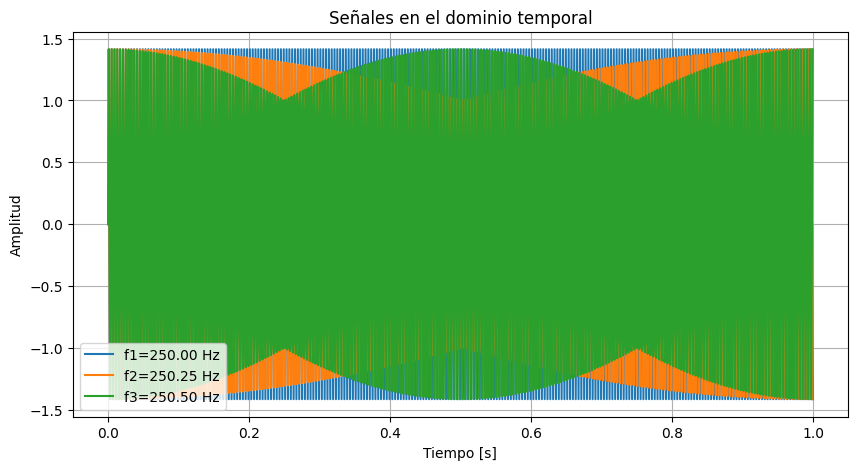

In [3]:
vmax = np.sqrt(2)
k = [N/4, N/4 + 0.25, N/4 + 0.5]
ff1 = k[0]*deltaf
ff2 = k[1]*deltaf
ff3 = k[2]*deltaf

t, x1 = signal(wave='sine', vmax=vmax, dc=0, ff=ff1, ph=0, nn=N, fs=fs)
_, x2 = signal(wave='sine', vmax=vmax, dc=0, ff=ff2, ph=0, nn=N, fs=fs)
_, x3 = signal(wave='sine', vmax=vmax, dc=0, ff=ff3, ph=0, nn=N, fs=fs)

#%% Grafico Temporal
plt.figure(figsize=(10,5))
plt.plot(t, x1, label=f'f1={ff1:.2f} Hz')
plt.plot(t, x2, label=f'f2={ff2:.2f} Hz')
plt.plot(t, x3, label=f'f3={ff3:.2f} Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señales en el dominio temporal')
plt.legend()
plt.grid()
plt.show()

### Verificamos la potencia unitaria:

In [4]:
# FFT
X1 = np.fft.fft(x1)/N
X2 = np.fft.fft(x2)/N
X3 = np.fft.fft(x3)/N

f  = np.arange(start = 0, stop = fs, step = deltaf)

# Potencia desde tiempo
P1 = np.mean(np.abs(x1)**2)
P2 = np.mean(np.abs(x2)**2)
P3 = np.mean(np.abs(x3)**2)

print("Potencias desde tiempo:")
print(f"P1 = {P1:.4f}")
print(f"P2 = {P2:.4f}")
print(f"P3 = {P3:.4f}")

# Potencia desde FFT (verificación)
P1f = np.sum(np.abs(X1)**2)
P2f = np.sum(np.abs(X2)**2)
P3f = np.sum(np.abs(X3)**2)

print("\nPotencias desde FFT:")
print(f"P1f = {P1f:.4f}")
print(f"P2f = {P2f:.4f}")
print(f"P3f = {P3f:.4f}")

Potencias desde tiempo:
P1 = 1.0000
P2 = 0.9990
P3 = 1.0000

Potencias desde FFT:
P1f = 1.0000
P2f = 0.9990
P3f = 1.0000


### Gráfico PSD:

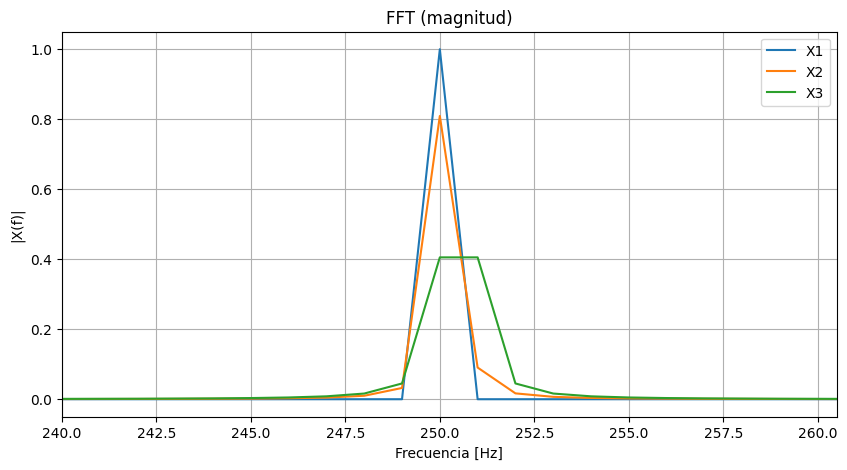

In [9]:
plt.figure(figsize=(10,5))
plt.plot(f,2*(np.abs(X1))**2, label='X1')
plt.plot(f,2*(np.abs(X2))**2, label='X2')
plt.plot(f,2*(np.abs(X3))**2, label='X3')
plt.xlim([ff1 - 10*deltaf, ff3 + 10*deltaf])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|X(f)|')
plt.title('FFT (magnitud)')
plt.legend()

plt.grid()
plt.show()

## Bonus: Zero Padding.

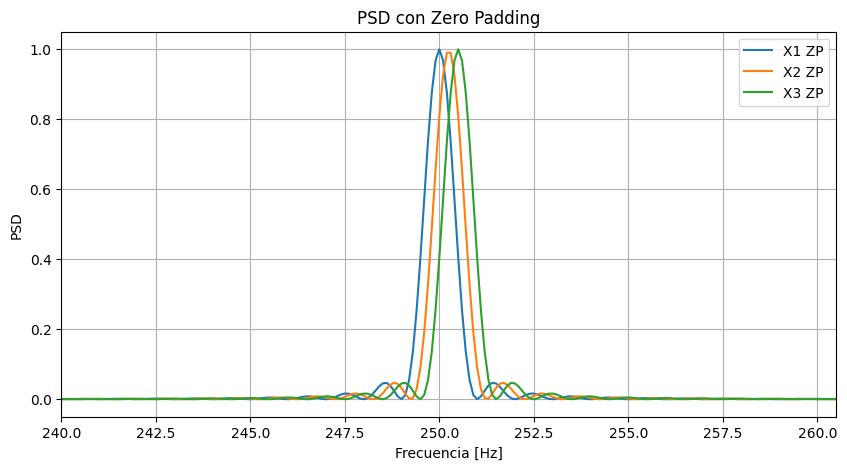

In [11]:
Np = 9*N
Nt = N + Np

x1_zp = np.pad(x1, (0, Np),'constant', constant_values=0)
x2_zp = np.pad(x2, (0, Np),'constant', constant_values=0)
x3_zp = np.pad(x3, (0, Np),'constant', constant_values=0)

X1_zp = np.fft.fft(x1_zp)/N
X2_zp = np.fft.fft(x2_zp)/N
X3_zp = np.fft.fft(x3_zp)/N

fz  = np.arange(Nt) * fs / Nt

plt.figure(figsize=(10,5))
plt.plot(fz,2*(np.abs(X1_zp)**2), label='X1 ZP')
plt.plot(fz,2*(np.abs(X2_zp)**2), label='X2 ZP')
plt.plot(fz,2*(np.abs(X3_zp)**2), label='X3 ZP')

plt.xlim([ff1 - 10*deltaf, ff3 + 10*deltaf])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD con Zero Padding')
plt.legend()
plt.grid()
plt.show()


Como podemos observar, logramos aumentar la resolución espectral de forma artificial, obteniendo así un gráfico mucho mas detallado. Por otro lado, notamos que para obtener la magnitud correcta ya no debemos normalizar la FFT por la cantidad total de muestras (Nt) sino por la cantidad de muestras no nulas (N).